In [2]:
# Install libraries directly within the notebook
%pip install pandas matplotlib seaborn scikit-learn textblob networkx spacy wordcloud
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   --------------------------------- ------ 524.3/625.0 kB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 625.0/625.0 kB 2.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.1 MB 4.1 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.9 MB/s  0:00:00
   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
   -- ------------------------------------- 1.0/14.4 MB 5.2 MB/s eta 0:00:03
   ------- -------------------------------- 2.6/14.4 MB 6.2 MB/s eta 0:00:02
   ---------- ----------------------------- 3.7/14.4 MB 5.9 MB/s eta 0:00:02
   -------------- ------------------------- 5.2/14.4 MB 6.2 MB/s eta 0:00:02
   -------------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 4.0 MB/s eta 0:00:04
     -- ------------------------------------- 0.8/12.8 MB 1.3 MB/s eta 0:00:09
     ------ --------------------------------- 2.1/12.8 MB 2.9 MB/s eta 0:00:04
     ---------- ----------------------------- 3.4/12.8 MB 3.8 MB/s eta 0:00:03
     -------------- ------------------------- 4.7/12.8 MB 4.2 MB/s eta 0:00:02
     ------------------ --------------------- 6.0/12.8 MB 4.5 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 4.5 MB/s eta 0:00:02
     -------------------------- ------------- 8.4/12.8 MB 4.8 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 5.1 MB/s eta 0:00:01
     ---------------------------------- ----- 11.0/12.8 MB 5.2 MB/


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import warnings

# Ignore minor warnings to keep the notebook clean
warnings.filterwarnings('ignore')

# Set beautiful default aesthetics for Jupyter plots
sns.set_theme(style="whitegrid", palette="muted", context="notebook")
plt.rcParams['figure.figsize'] = (14, 8)

# Load data
print("Loading data...")
df = pd.read_csv("Final_Cleaned_Passenger_Data.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['text_clean'] = df['text_clean'].fillna('')

# Calculate base sentiment
print("Calculating base sentiment...")
df['sentiment'] = df['text_clean'].apply(lambda x: TextBlob(x).sentiment.polarity)
print("Data loaded and sentiment calculated successfully!")

Loading data...
Calculating base sentiment...
Data loaded and sentiment calculated successfully!


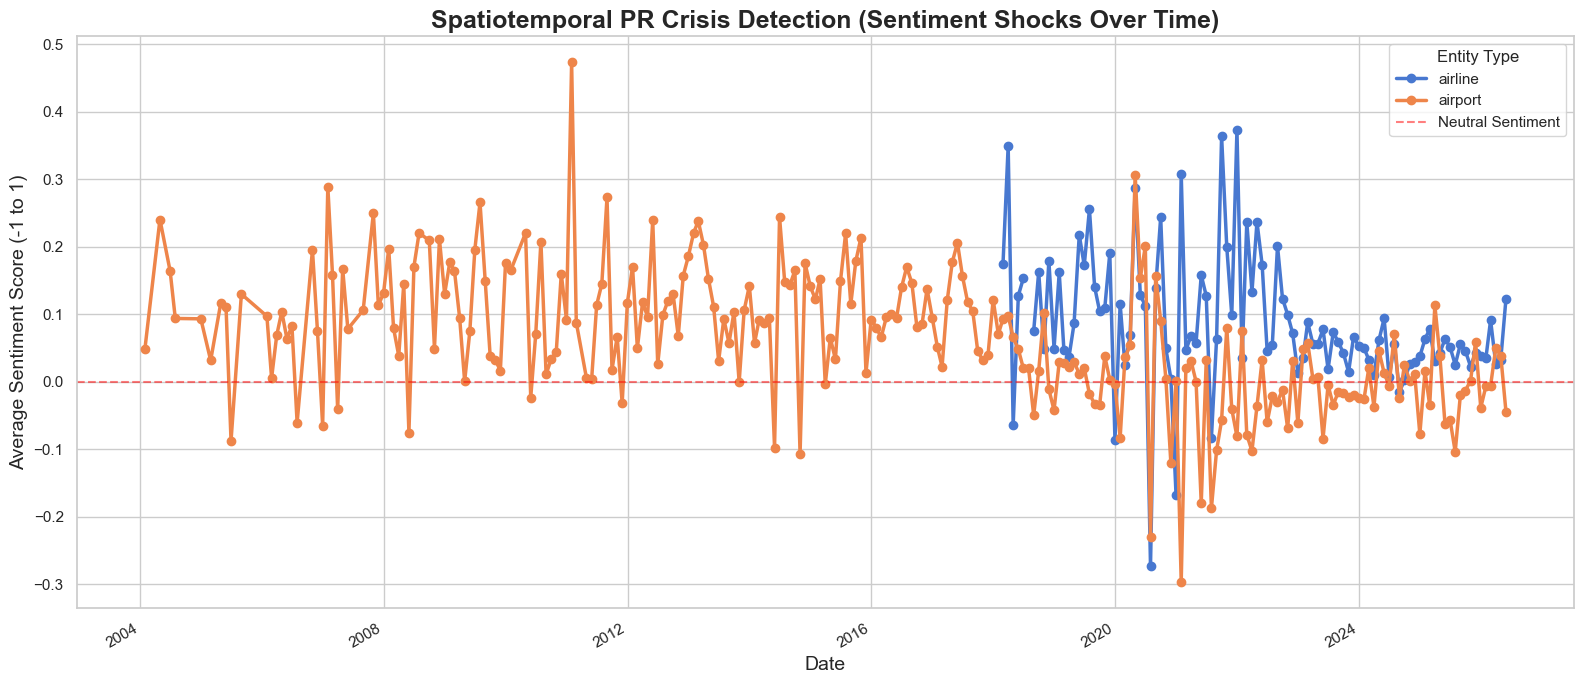

In [5]:
# Group by Month-Year for smoother trend lines
df_time = df.dropna(subset=['date']).copy()
df_time.set_index('date', inplace=True)
monthly_sentiment = df_time.groupby([pd.Grouper(freq='ME'), 'source_target_type'])['sentiment'].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 7))
monthly_sentiment.plot(ax=ax, linewidth=2.5, marker='o', markersize=6)

plt.title('Spatiotemporal PR Crisis Detection (Sentiment Shocks Over Time)', fontsize=18, fontweight='bold')
plt.ylabel('Average Sentiment Score (-1 to 1)', fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Neutral Sentiment')
plt.legend(title='Entity Type')
plt.tight_layout()
plt.show()

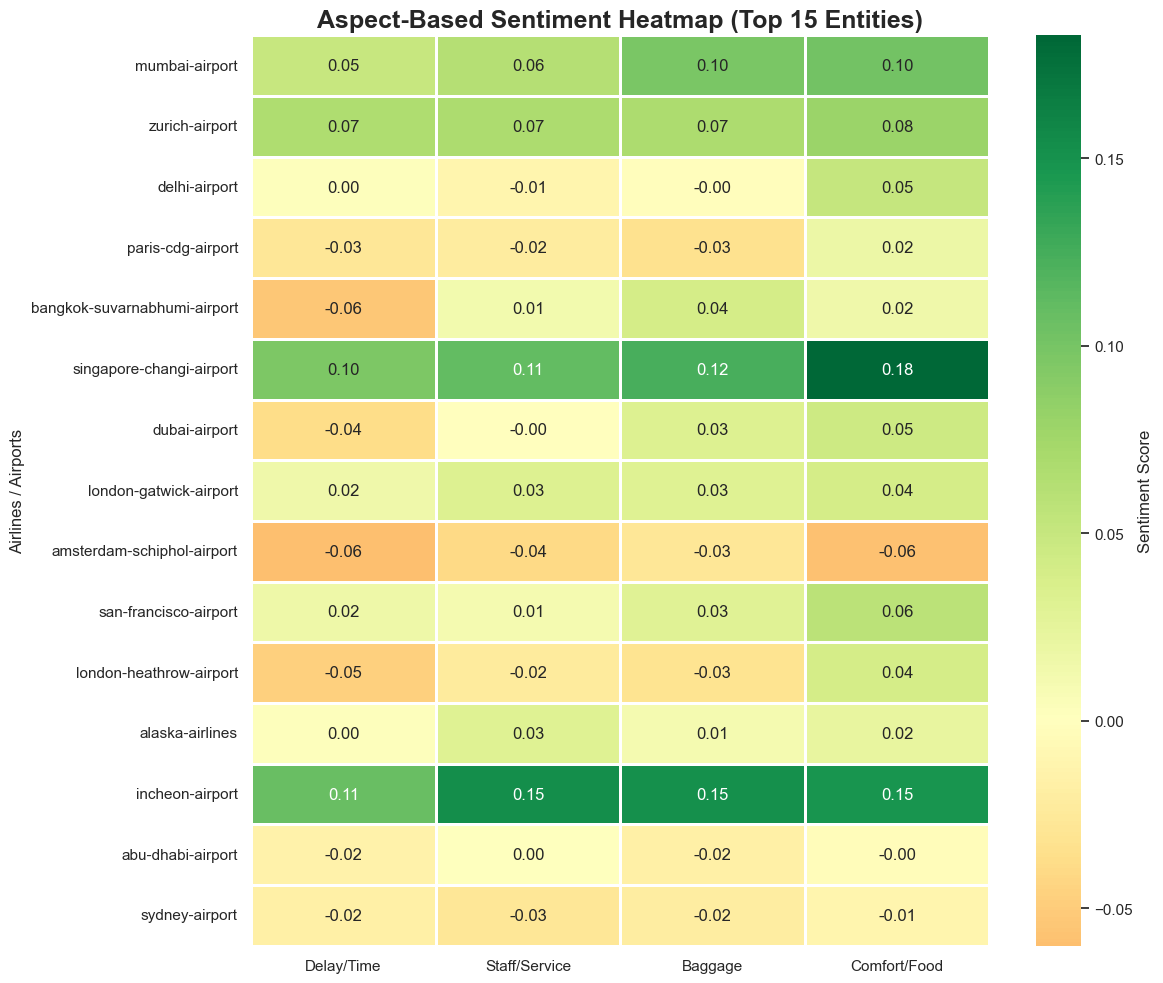

In [6]:
aspects = {
    'Delay/Time': ['delay', 'wait', 'late', 'hour', 'cancelled', 'missed'],
    'Staff/Service': ['staff', 'crew', 'attendant', 'rude', 'helpful', 'service'],
    'Baggage': ['baggage', 'luggage', 'bag', 'lost', 'claim'],
    'Comfort/Food': ['food', 'seat', 'legroom', 'meal', 'lounge']
}

# Count mentions of aspects
aspect_scores = pd.DataFrame(index=df['source_target'].value_counts().head(15).index, columns=aspects.keys())

for entity in aspect_scores.index:
    entity_df = df[df['source_target'] == entity]
    for aspect, keywords in aspects.items():
        mask = entity_df['text_clean'].str.contains('|'.join(keywords), case=False, na=False)
        if mask.sum() > 0:
            aspect_scores.loc[entity, aspect] = entity_df[mask]['sentiment'].mean()
        else:
            aspect_scores.loc[entity, aspect] = np.nan

aspect_scores = aspect_scores.astype(float)

plt.figure(figsize=(12, 10))
sns.heatmap(aspect_scores, annot=True, cmap='RdYlGn', center=0, fmt='.2f', 
            linewidths=1, linecolor='white', cbar_kws={'label': 'Sentiment Score'})
plt.title('Aspect-Based Sentiment Heatmap (Top 15 Entities)', fontsize=18, fontweight='bold')
plt.ylabel('Airlines / Airports')
plt.tight_layout()
plt.show()

Categorizing complaints... (This will take a few seconds)


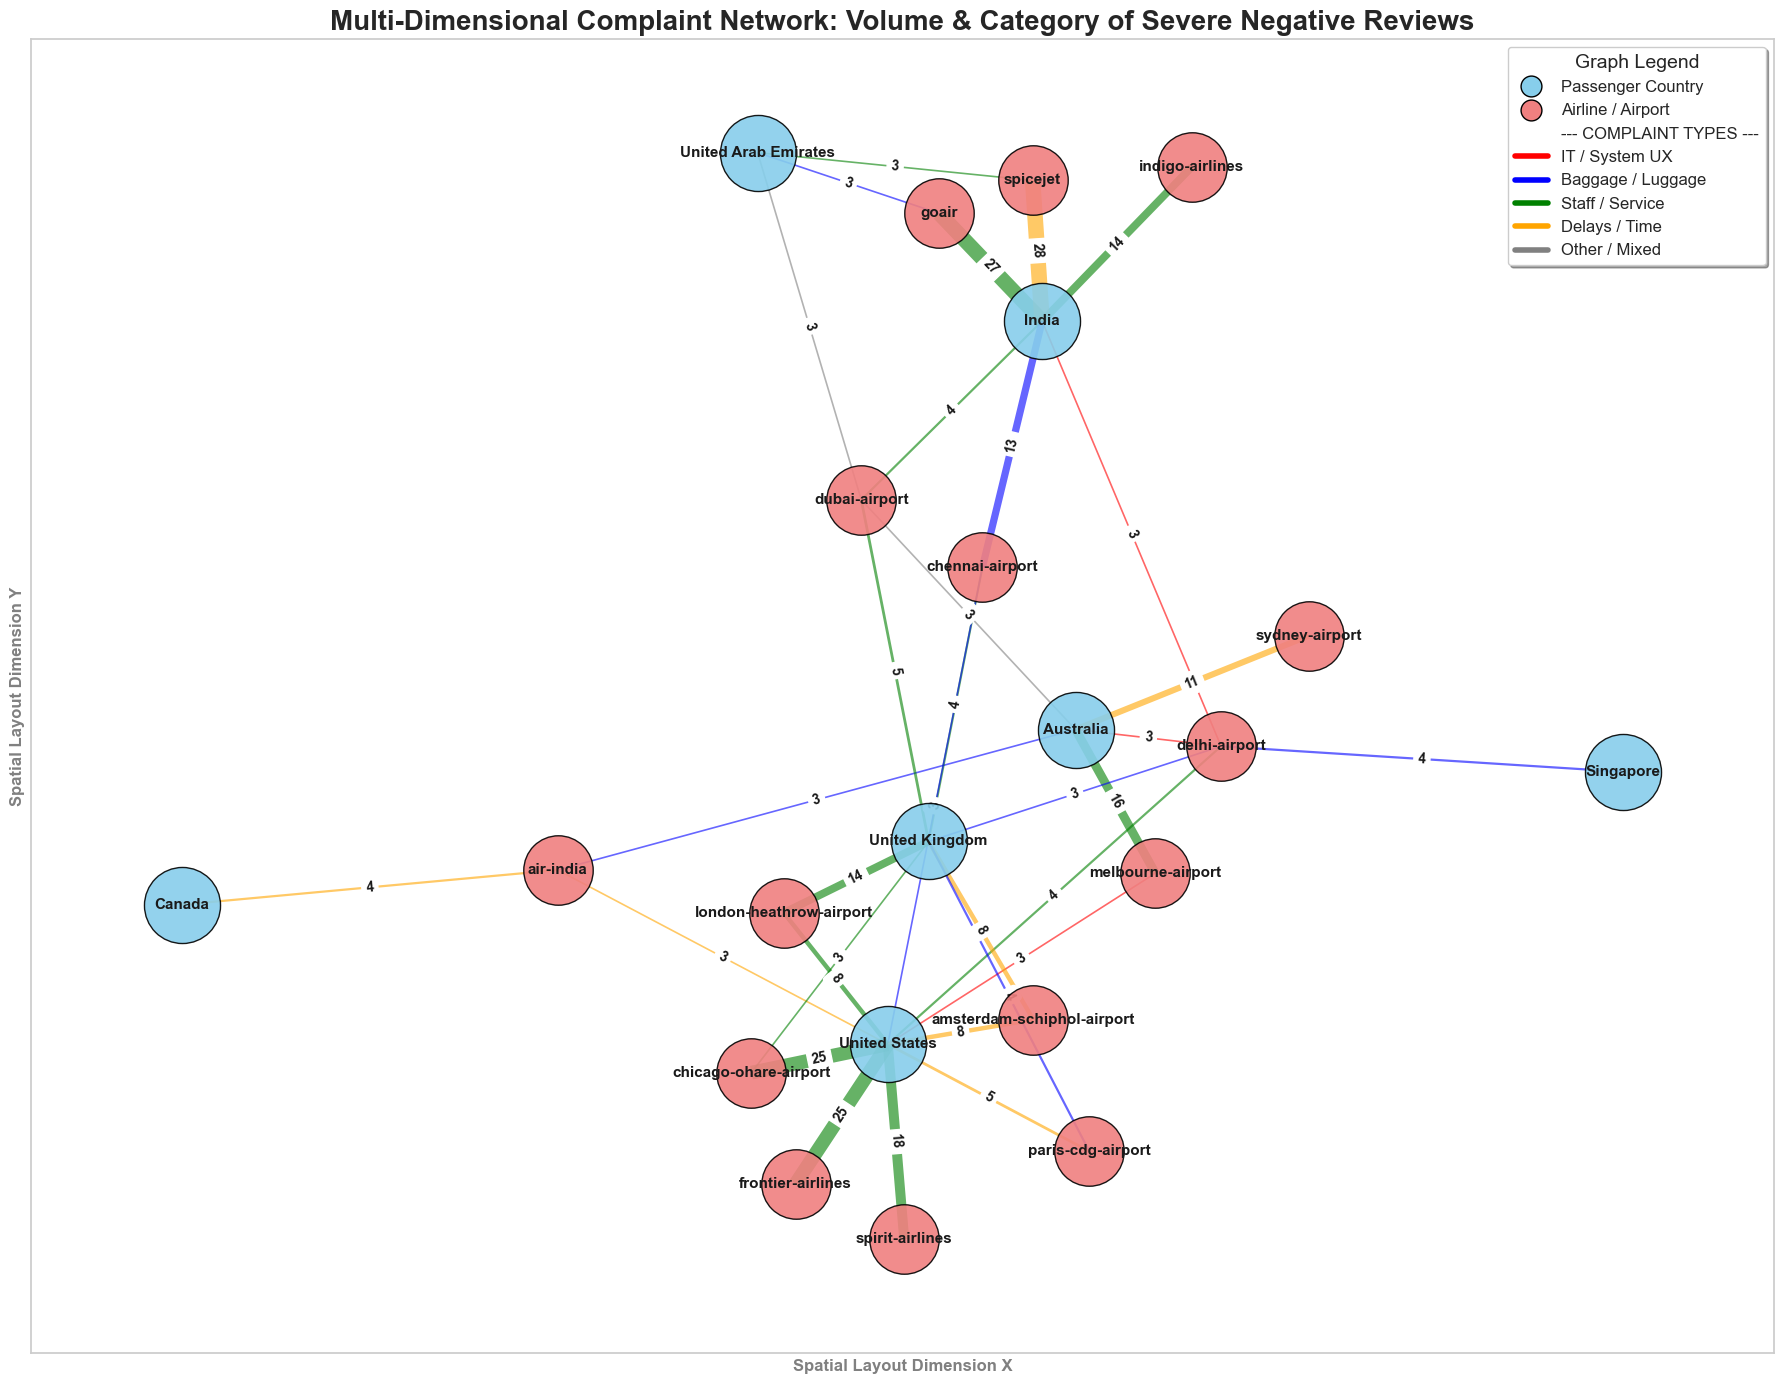

In [14]:
import matplotlib.lines as mlines
import warnings
warnings.filterwarnings('ignore')

# 1. Define our Strategic Categories and Keywords
categories = {
    'IT / System UX': ['app', 'website', 'system', 'kiosk', 'epassport', 'online', 'booking', 'check-in', 'software'],
    'Baggage / Luggage': ['baggage', 'luggage', 'bag', 'lost', 'claim'],
    'Staff / Service': ['staff', 'crew', 'attendant', 'rude', 'service', 'customer', 'agent'],
    'Delays / Time': ['delay', 'wait', 'late', 'hour', 'cancelled', 'missed']
}

# 2. Function to categorize a review based on keyword density
def get_dominant_category(text):
    text = str(text).lower()
    counts = {cat: sum(text.count(word) for word in words) for cat, words in categories.items()}
    best_cat = max(counts, key=counts.get)
    return best_cat if counts[best_cat] > 0 else 'Other/Mixed'

print("Categorizing complaints... (This will take a few seconds)")

# Filter for severe negative reviews
negative_df = df[(df['sentiment'] < -0.2) & (df['country'].notna())].copy()

# Apply the category function
negative_df['category'] = negative_df['text_clean'].apply(get_dominant_category)

# Get Top Countries and Entities
top_countries = negative_df['country'].value_counts().head(10).index
top_entities = negative_df['source_target'].value_counts().head(15).index

network_data = negative_df[negative_df['country'].isin(top_countries) & 
                           negative_df['source_target'].isin(top_entities)]

# 3. Aggregate weights AND the dominant category for that specific route
edges = network_data.groupby(['country', 'source_target']).agg(
    weight=('category', 'size'),
    dominant_category=('category', lambda x: x.value_counts().idxmax())
).reset_index()

# Build Graph
G = nx.Graph()
for _, row in edges.iterrows():
    if row['weight'] > 2: # Filter weak links to keep graph clean
        G.add_edge(row['country'], row['source_target'], 
                   weight=row['weight'], 
                   category=row['dominant_category'])

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, k=0.6, iterations=50)

countries = [node for node in G.nodes() if node in top_countries]
entities = [node for node in G.nodes() if node not in top_countries]

# 4. Draw Nodes
nx.draw_networkx_nodes(G, pos, nodelist=countries, node_color='skyblue', node_size=3000, alpha=0.9, edgecolors='black')
nx.draw_networkx_nodes(G, pos, nodelist=entities, node_color='lightcoral', node_size=2500, alpha=0.9, edgecolors='black')

# 5. Draw Edges with Colors Based on Category
color_map = {
    'IT / System UX': 'red',
    'Baggage / Luggage': 'blue',
    'Staff / Service': 'green',
    'Delays / Time': 'orange',
    'Other/Mixed': 'gray'
}

edge_colors = [color_map[G[u][v]['category']] for u, v in G.edges()]
edge_weights = [G[u][v]['weight'] * 0.4 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=0.6)

# 6. Add Node Labels and Edge Labels (Complaint Volume)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold")

edge_labels = {(u, v): G[u][v]['weight'] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_weight='bold')

# 7. Build Comprehensive Legend
# 7. Build Comprehensive Legend (Fixed Line2D arguments)
legend_elements = [
    mlines.Line2D([], [], color='skyblue', marker='o', linestyle='None', markersize=15, label='Passenger Country', markeredgecolor='black'),
    mlines.Line2D([], [], color='lightcoral', marker='o', linestyle='None', markersize=15, label='Airline / Airport', markeredgecolor='black'),
    # Removed the invalid fontsize/fontweight arguments here:
    mlines.Line2D([], [], color='white', marker='none', label='--- COMPLAINT TYPES ---'),
    mlines.Line2D([], [], color='red', linewidth=4, label='IT / System UX'),
    mlines.Line2D([], [], color='blue', linewidth=4, label='Baggage / Luggage'),
    mlines.Line2D([], [], color='green', linewidth=4, label='Staff / Service'),
    mlines.Line2D([], [], color='orange', linewidth=4, label='Delays / Time'),
    mlines.Line2D([], [], color='gray', linewidth=4, label='Other / Mixed')
]

plt.legend(handles=legend_elements, loc='upper right', title='Graph Legend', fontsize=12, title_fontsize=14, shadow=True)

plt.legend(handles=legend_elements, loc='upper right', title='Graph Legend', fontsize=12, title_fontsize=14, shadow=True)

# 8. Axis Labels & Title
plt.xlabel('Spatial Layout Dimension X', fontsize=12, fontweight='bold', color='gray')
plt.ylabel('Spatial Layout Dimension Y', fontsize=12, fontweight='bold', color='gray')
plt.xticks([])
plt.yticks([])
plt.title('Multi-Dimensional Complaint Network: Volume & Category of Severe Negative Reviews', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

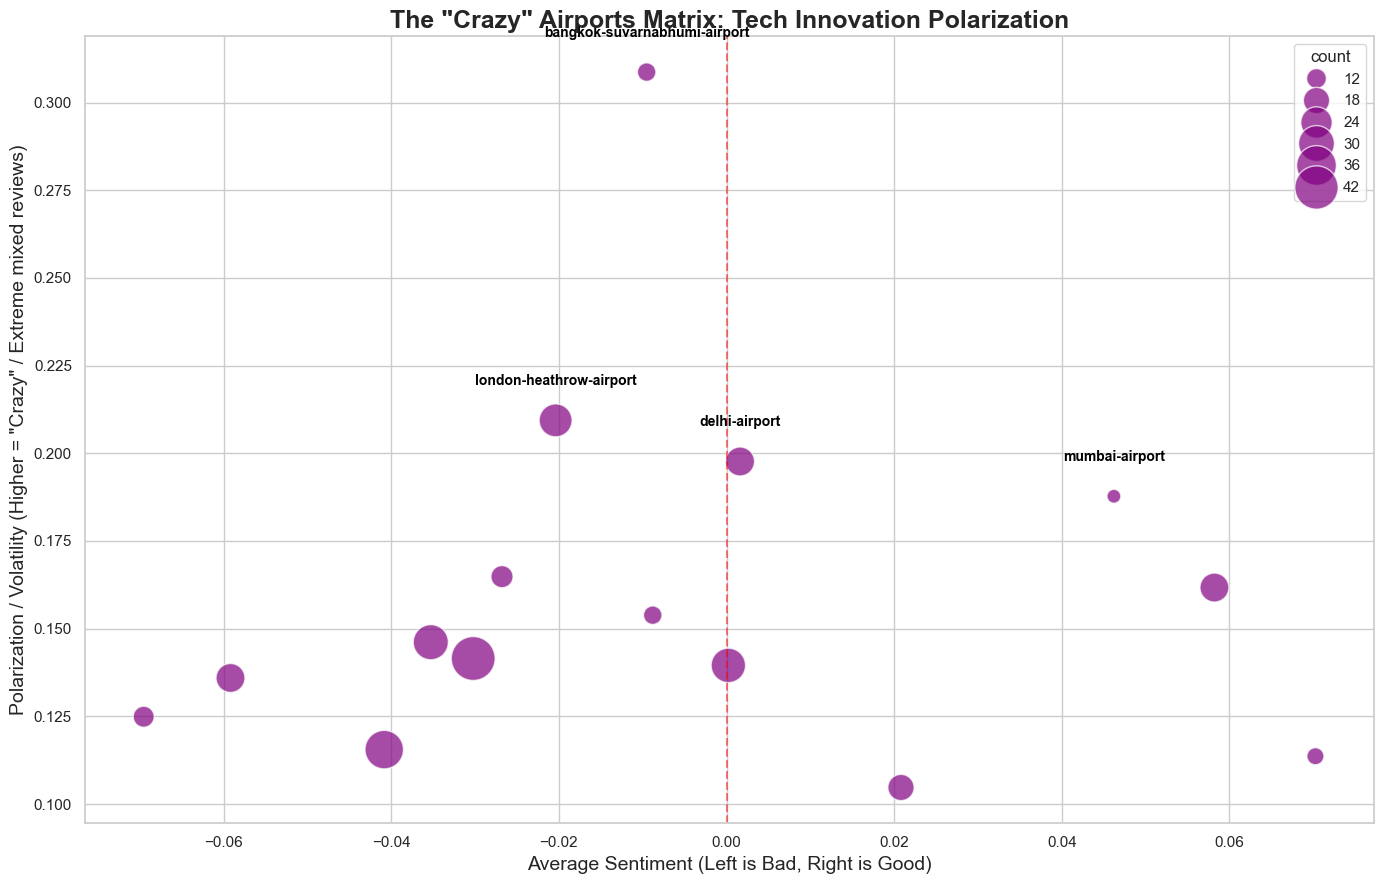

In [16]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
recent_df = df[df['date'].dt.year >= 2023].copy()

# 1. Filter for tech-related reviews for Airports only
tech_keywords = ['kiosk', 'system', 'machine', 'automation', 'epassport', 'app', 'scan']
mask = recent_df['text_clean'].str.contains('|'.join(tech_keywords), case=False, na=False)
airport_tech_df = recent_df[mask & (recent_df['source_target_type'] == 'airport')].copy()

# Calculate sentiment
airport_tech_df['sentiment'] = airport_tech_df['text_clean'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Group by Airport
crazy_airports = airport_tech_df.groupby('source_target')['sentiment'].agg(['mean', 'std', 'count']).dropna()
crazy_airports = crazy_airports[crazy_airports['count'] > 5] # Minimum mentions

# 2. Plot the Polarization Matrix
plt.figure(figsize=(14, 9))
sns.scatterplot(data=crazy_airports, x='mean', y='std', size='count', sizes=(100, 1000), alpha=0.7, color='purple')

# Add labels to the "craziest" ones (High Variance / STD)
for line in range(0, crazy_airports.shape[0]):
    if crazy_airports['std'].iloc[line] > crazy_airports['std'].quantile(0.75): # Top 25% most polarized
        plt.text(crazy_airports['mean'].iloc[line], 
                 crazy_airports['std'].iloc[line]+0.01, 
                 crazy_airports.index[line], horizontalalignment='center', 
                 size='small', color='black', weight='bold')

plt.title('The "Crazy" Airports Matrix: Tech Innovation Polarization', fontsize=18, fontweight='bold')
plt.xlabel('Average Sentiment (Left is Bad, Right is Good)', fontsize=14)
plt.ylabel('Polarization / Volatility (Higher = "Crazy" / Extreme mixed reviews)', fontsize=14)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Categorizing positive reviews... (This will take a few seconds)


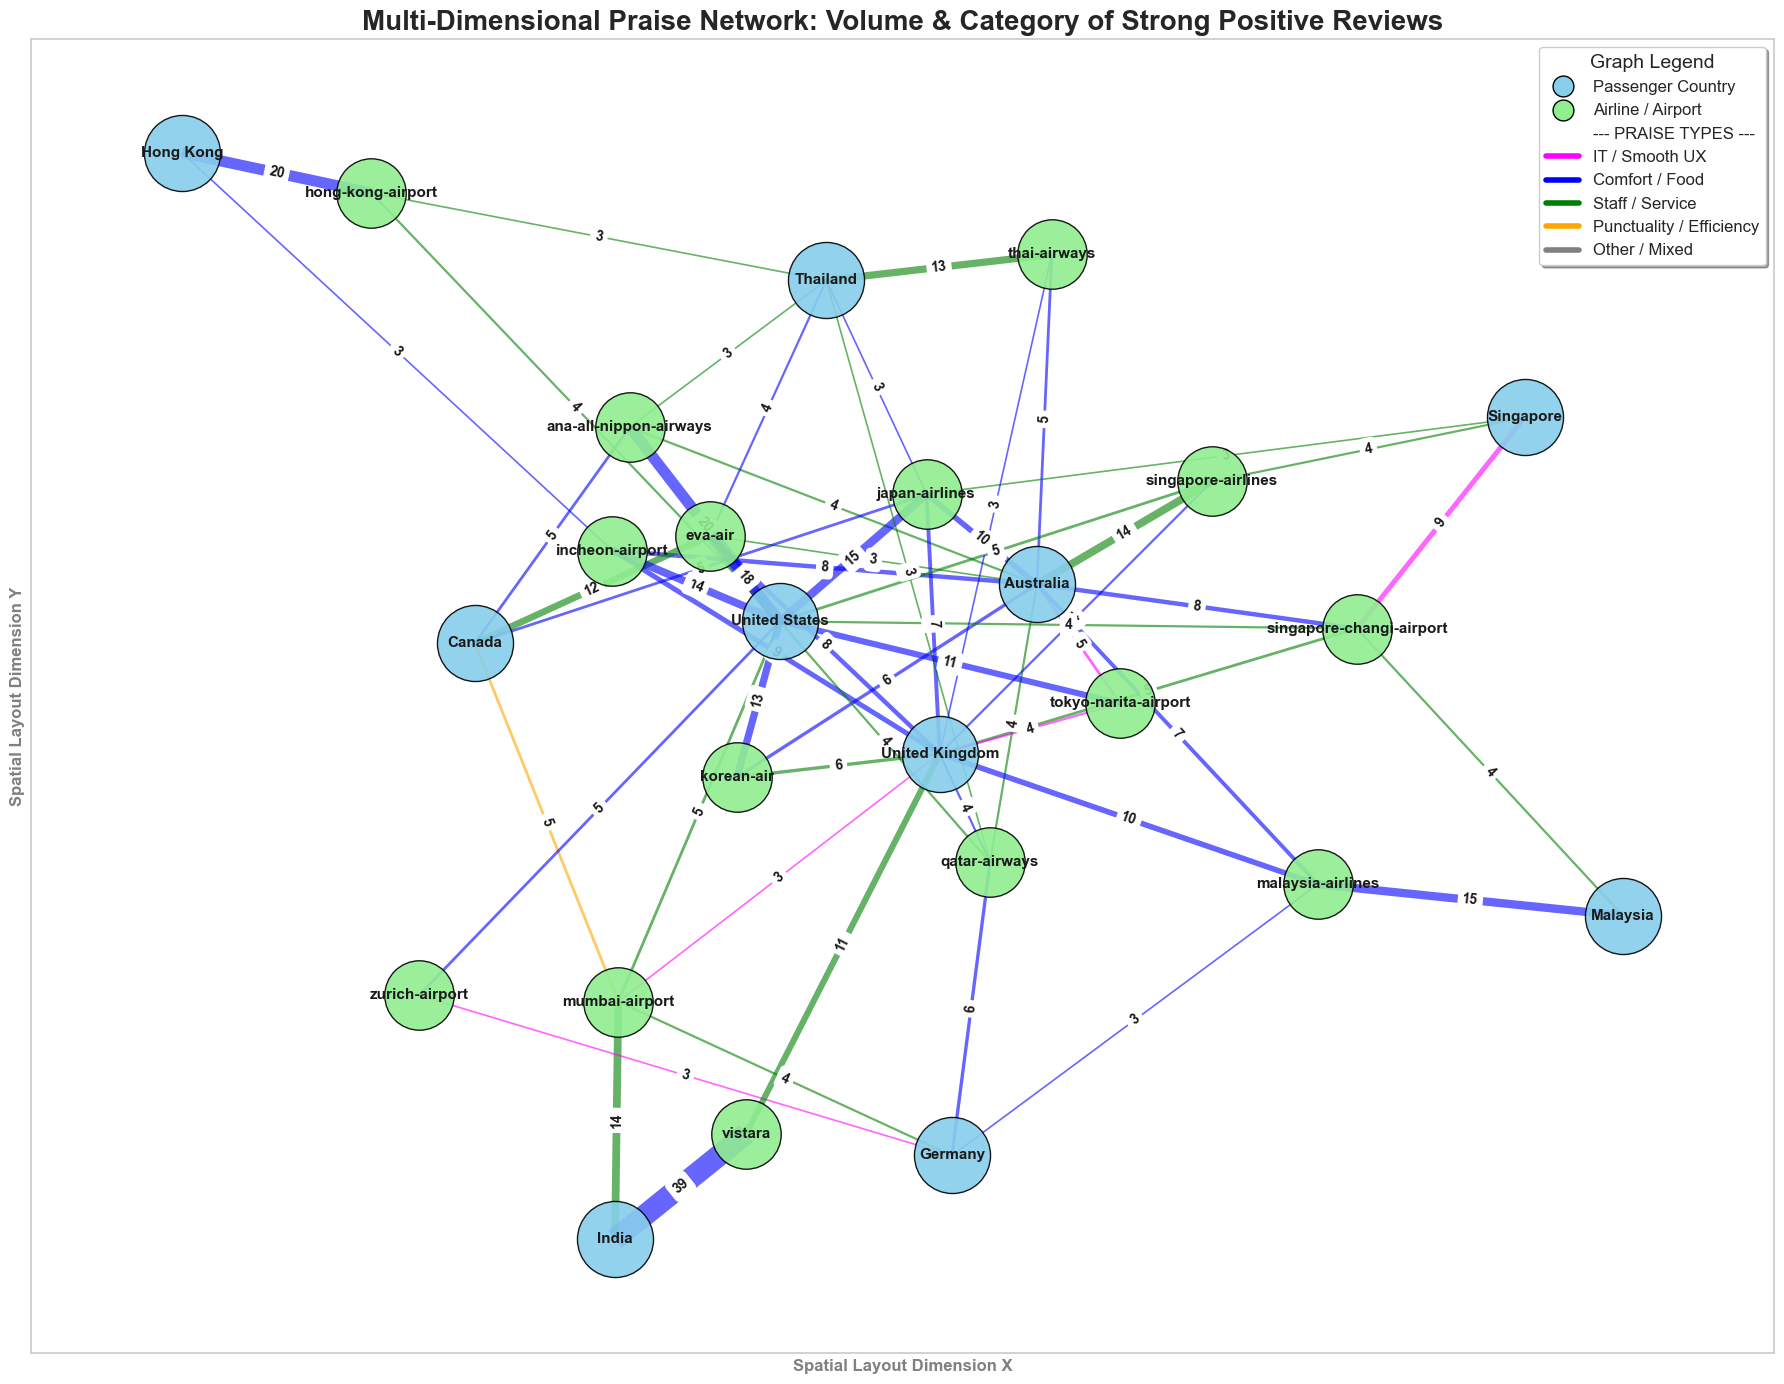

In [17]:
# 1. Define our Strategic Categories and Keywords for POSITIVE experiences
categories_positive = {
    'IT / Smooth UX': ['app', 'website', 'easy', 'fast', 'smooth', 'kiosk', 'seamless', 'online', 'quick'],
    'Comfort / Food': ['comfortable', 'clean', 'lounge', 'seat', 'food', 'meal', 'space', 'entertainment'],
    'Staff / Service': ['friendly', 'helpful', 'staff', 'crew', 'smile', 'service', 'professional', 'attentive'],
    'Punctuality / Efficiency': ['time', 'early', 'punctual', 'efficient', 'schedule']
}

# 2. Function to categorize a review based on positive keyword density
def get_dominant_positive_category(text):
    text = str(text).lower()
    counts = {cat: sum(text.count(word) for word in words) for cat, words in categories_positive.items()}
    best_cat = max(counts, key=counts.get)
    return best_cat if counts[best_cat] > 0 else 'Other/Mixed'

print("Categorizing positive reviews... (This will take a few seconds)")

# Filter for strong POSITIVE reviews (Sentiment > 0.2)
positive_df = df[(df['sentiment'] > 0.2) & (df['country'].notna())].copy()

# Apply the positive category function
positive_df['category'] = positive_df['text_clean'].apply(get_dominant_positive_category)

# Get Top Countries and Entities for the positive dataset
top_countries = positive_df['country'].value_counts().head(10).index
top_entities = positive_df['source_target'].value_counts().head(15).index

network_data = positive_df[positive_df['country'].isin(top_countries) & 
                           positive_df['source_target'].isin(top_entities)]

# 3. Aggregate weights AND the dominant category for that specific route
edges = network_data.groupby(['country', 'source_target']).agg(
    weight=('category', 'size'),
    dominant_category=('category', lambda x: x.value_counts().idxmax())
).reset_index()

# Build Graph
G = nx.Graph()
for _, row in edges.iterrows():
    if row['weight'] > 2: # Filter weak links to keep graph clean
        G.add_edge(row['country'], row['source_target'], 
                   weight=row['weight'], 
                   category=row['dominant_category'])

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, k=0.6, iterations=50)

countries = [node for node in G.nodes() if node in top_countries]
entities = [node for node in G.nodes() if node not in top_countries]

# 4. Draw Nodes
nx.draw_networkx_nodes(G, pos, nodelist=countries, node_color='skyblue', node_size=3000, alpha=0.9, edgecolors='black')
nx.draw_networkx_nodes(G, pos, nodelist=entities, node_color='lightgreen', node_size=2500, alpha=0.9, edgecolors='black')

# 5. Draw Edges with Colors Based on Positive Categories
color_map = {
    'IT / Smooth UX': 'magenta',
    'Comfort / Food': 'blue',
    'Staff / Service': 'green',
    'Punctuality / Efficiency': 'orange',
    'Other/Mixed': 'gray'
}

edge_colors = [color_map[G[u][v]['category']] for u, v in G.edges()]
edge_weights = [G[u][v]['weight'] * 0.4 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=0.6)

# 6. Add Node Labels and Edge Labels (Praise Volume)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold")

edge_labels = {(u, v): G[u][v]['weight'] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_weight='bold')

# 7. Build Comprehensive Legend for Positive Attributes
legend_elements = [
    mlines.Line2D([], [], color='skyblue', marker='o', linestyle='None', markersize=15, label='Passenger Country', markeredgecolor='black'),
    mlines.Line2D([], [], color='lightgreen', marker='o', linestyle='None', markersize=15, label='Airline / Airport', markeredgecolor='black'),
    mlines.Line2D([], [], color='white', marker='none', label='--- PRAISE TYPES ---'),
    mlines.Line2D([], [], color='magenta', linewidth=4, label='IT / Smooth UX'),
    mlines.Line2D([], [], color='blue', linewidth=4, label='Comfort / Food'),
    mlines.Line2D([], [], color='green', linewidth=4, label='Staff / Service'),
    mlines.Line2D([], [], color='orange', linewidth=4, label='Punctuality / Efficiency'),
    mlines.Line2D([], [], color='gray', linewidth=4, label='Other / Mixed')
]

plt.legend(handles=legend_elements, loc='upper right', title='Graph Legend', fontsize=12, title_fontsize=14, shadow=True)

# 8. Axis Labels & Title
plt.xlabel('Spatial Layout Dimension X', fontsize=12, fontweight='bold', color='gray')
plt.ylabel('Spatial Layout Dimension Y', fontsize=12, fontweight='bold', color='gray')
plt.xticks([])
plt.yticks([])
plt.title('Multi-Dimensional Praise Network: Volume & Category of Strong Positive Reviews', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
positive_df.head()

,text_clean,source_target,source_target_type,country,date,sentiment,category
8,check in at lgw was quick and easy flight to d...,emirates,airline,United Kingdom,2026-02-13,0.313264,IT / Smooth UX
18,hong kong check in unfriendly and brusque staf...,emirates,airline,Hong Kong,2025-12-14,0.328486,Staff / Service
21,new aircraft and good service for this short h...,emirates,airline,Australia,2025-11-25,0.248636,Comfort / Food
31,geneva to dubai i was able to upgrade with poi...,emirates,airline,New Zealand,2025-10-01,0.291712,Comfort / Food
33,the emirates chauffeur service is superb and c...,emirates,airline,South Africa,2025-09-18,0.298217,Comfort / Food


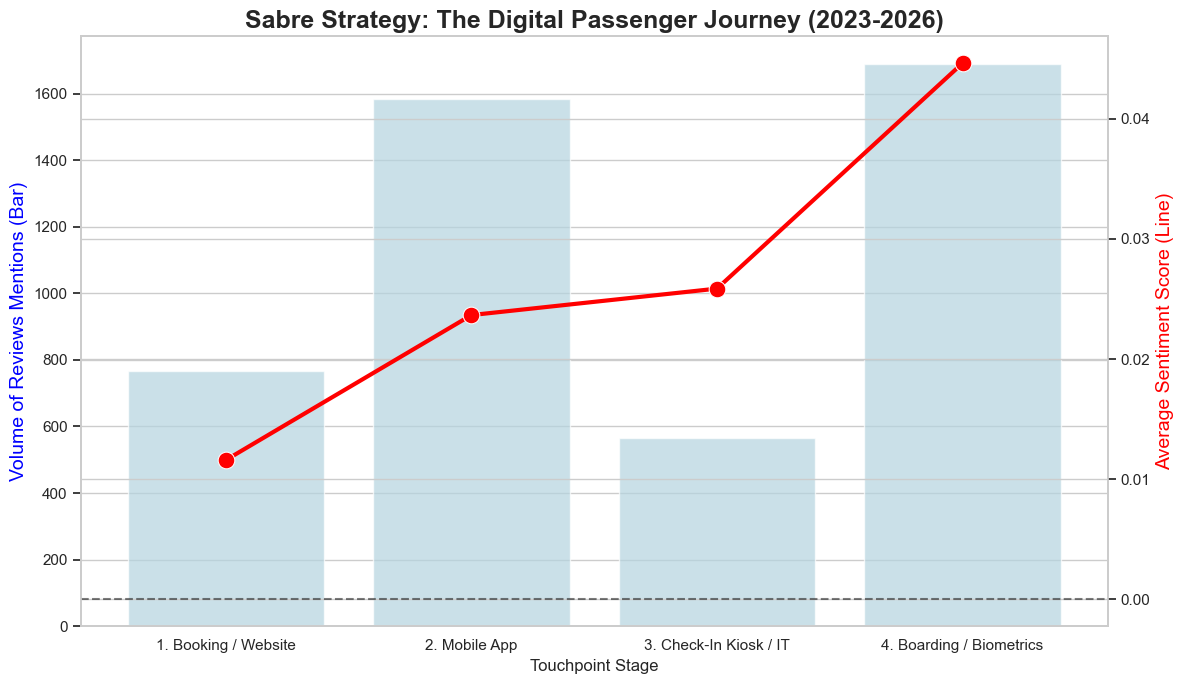

In [18]:
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# 1. Define Sabre-specific Touchpoints
touchpoints = {
    '1. Booking / Website': ['website', 'booking', 'online', 'payment', 'error'],
    '2. Mobile App': ['app', 'mobile', 'glitch', 'crash'],
    '3. Check-In Kiosk / IT': ['kiosk', 'system', 'machine', 'epassport', 'automation', 'scan'],
    '4. Boarding / Biometrics': ['boarding', 'gate', 'biometric', 'passport control']
}

df['date'] = pd.to_datetime(df['date'], errors='coerce')
recent_df = df[df['date'].dt.year >= 2023].copy() # Focus on recent UX

# 2. Calculate Sentiment per Touchpoint
funnel_data = []

for stage, keywords in touchpoints.items():
    mask = recent_df['text_clean'].str.contains('|'.join(keywords), case=False, na=False)
    stage_df = recent_df[mask].copy()
    stage_df['sentiment'] = stage_df['text_clean'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    
    funnel_data.append({
        'Touchpoint Stage': stage,
        'Volume': len(stage_df),
        'Average Sentiment': stage_df['sentiment'].mean()
    })

funnel_df = pd.DataFrame(funnel_data)

# 3. Plot the Digital Funnel
fig, ax1 = plt.subplots(figsize=(12, 7))

sns.barplot(data=funnel_df, x='Touchpoint Stage', y='Volume', color='lightblue', ax=ax1, alpha=0.7)
ax1.set_ylabel('Volume of Reviews Mentions (Bar)', fontsize=14, color='blue')
ax1.set_title('Sabre Strategy: The Digital Passenger Journey (2023-2026)', fontsize=18, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(data=funnel_df, x='Touchpoint Stage', y='Average Sentiment', color='red', marker='o', markersize=12, linewidth=3, ax=ax2)
ax2.set_ylabel('Average Sentiment Score (Line)', fontsize=14, color='red')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Extracting deep granular pain points using NLP... (This might take 30-60 seconds)


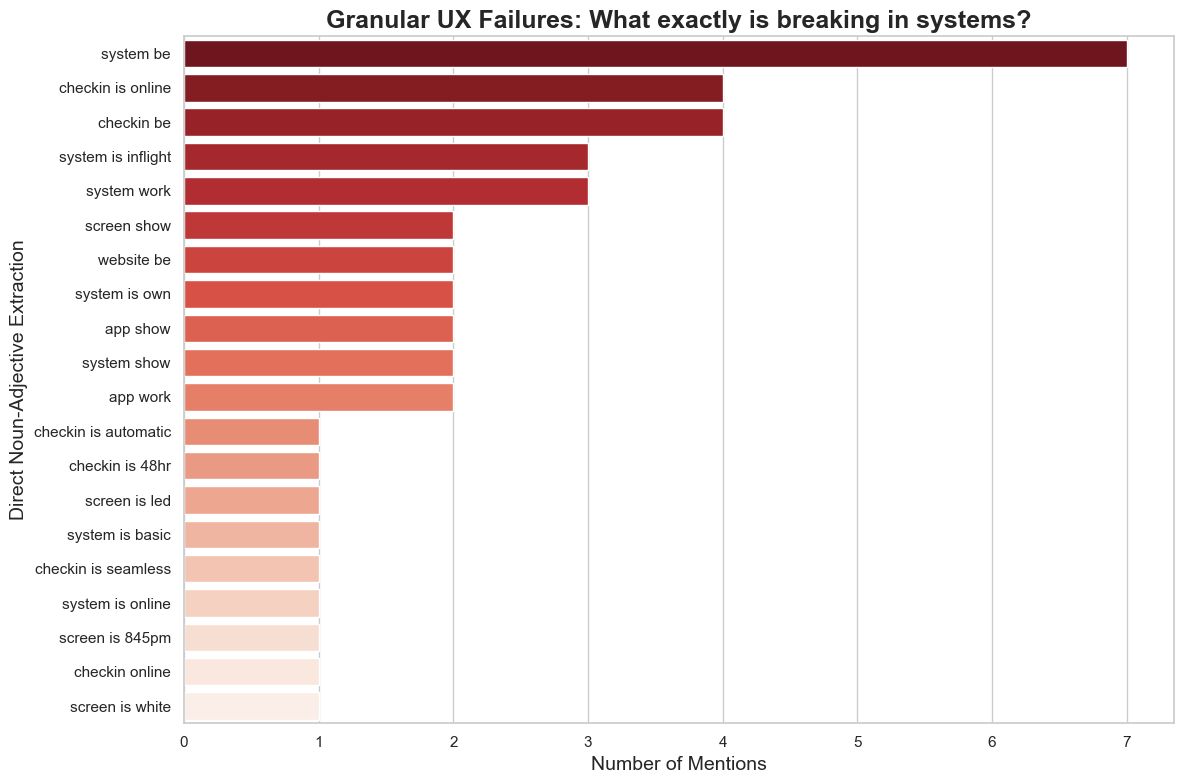

In [21]:
import spacy
from collections import Counter

# Load the NLP model (ensure you ran !python -m spacy download en_core_web_sm previously)
nlp = spacy.load("en_core_web_sm")

sabre_targets = ['app', 'website', 'system', 'kiosk', 'screen', 'checkin', 'software']

def get_pain_points(text):
    doc = nlp(str(text).lower())
    pain_points = []
    
    for token in doc:
        # Check if the word is a target tech word
        if token.lemma_ in sabre_targets:
            # Look for adjectives describing this word
            for child in token.children:
                if child.pos_ == "ADJ":
                    pain_points.append(f"{token.lemma_} is {child.lemma_}")
            
            # Look for verbs where the target is the subject (e.g. "app crashed")
            if token.dep_ == "nsubj":
                pain_points.append(f"{token.lemma_} {token.head.lemma_}")
                
    return pain_points

print("Extracting deep granular pain points using NLP... (This might take 30-60 seconds)")

all_pains = []
# Run on negative tech reviews to find what's broken
negative_tech = recent_df[(mask) & (recent_df['sentiment'] < 0)]['text_clean']

for text in negative_tech:
    all_pains.extend(get_pain_points(text))

# Count and plot the top specific issues
pain_counts = Counter(all_pains).most_common(20)
pain_df = pd.DataFrame(pain_counts, columns=['Specific IT Issue', 'Frequency'])

plt.figure(figsize=(12, 8))
sns.barplot(data=pain_df, y='Specific IT Issue', x='Frequency', palette='Reds_r')
plt.title('Granular UX Failures: What exactly is breaking in systems?', fontsize=18, fontweight='bold')
plt.xlabel('Number of Mentions', fontsize=14)
plt.ylabel('Direct Noun-Adjective Extraction', fontsize=14)
plt.tight_layout()
plt.show()

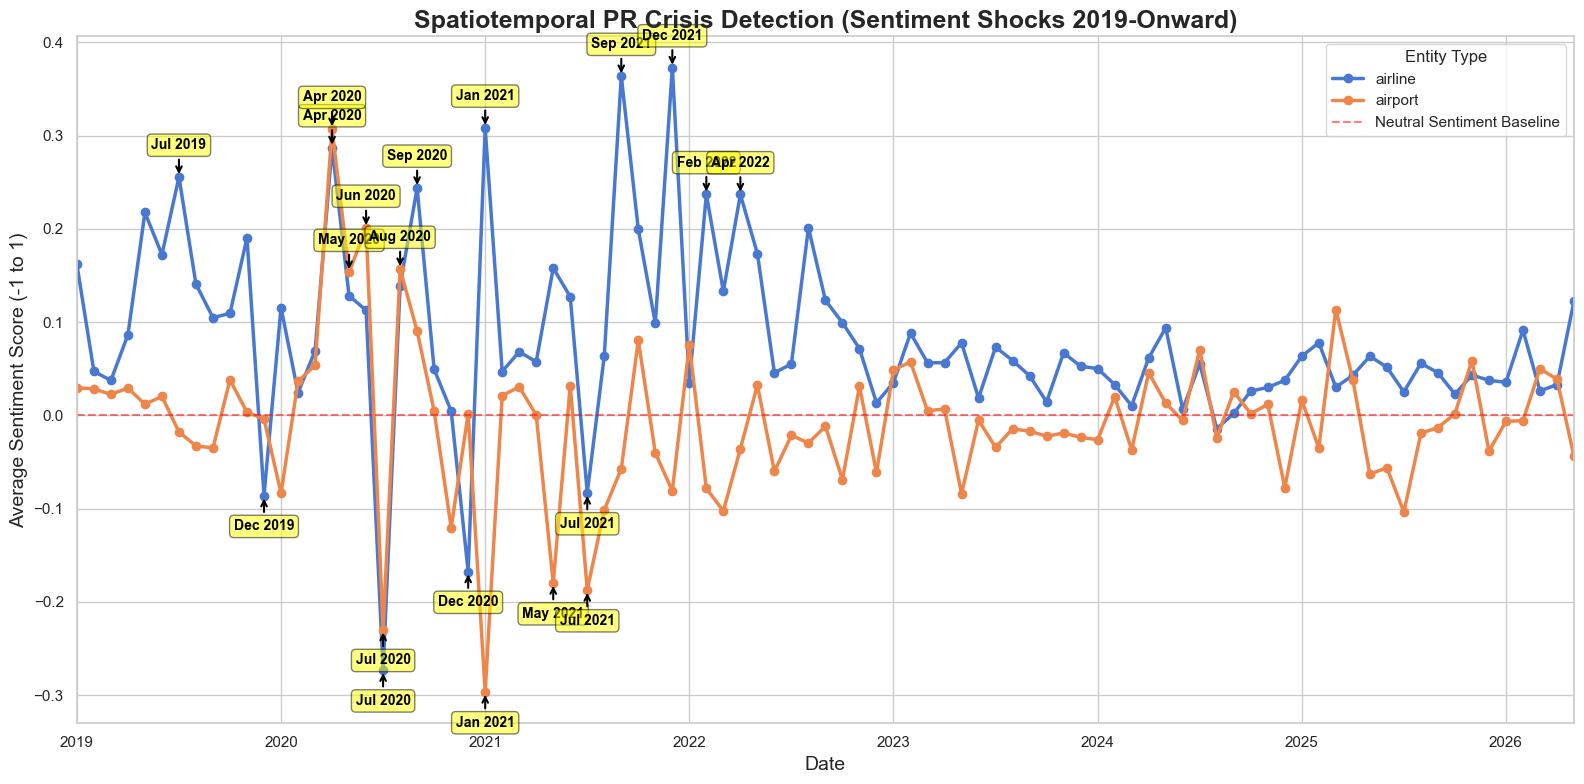

In [22]:

# 1. Group by Month-End for smoother trend lines
df_time = df.dropna(subset=['date']).copy()
df_time.set_index('date', inplace=True)

# 2. Filter for data explicitly AFTER 2018
df_time = df_time[df_time.index.year > 2018]

monthly_sentiment = df_time.groupby([pd.Grouper(freq='ME'), 'source_target_type'])['sentiment'].mean().unstack()

# 3. Plot the base chart
fig, ax = plt.subplots(figsize=(16, 8))
monthly_sentiment.plot(ax=ax, linewidth=2.5, marker='o', markersize=6)

plt.title('Spatiotemporal PR Crisis Detection (Sentiment Shocks 2019-Onward)', fontsize=18, fontweight='bold')
plt.ylabel('Average Sentiment Score (-1 to 1)', fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Neutral Sentiment Baseline')

# 4. Detect and Annotate the "Spikes" (Statistically significant anomalies)
for col in monthly_sentiment.columns:
    series = monthly_sentiment[col].dropna()
    if len(series) == 0:
        continue
        
    # Calculate what is "normal" for this entity type
    mean_val = series.mean()
    std_dev = series.std()
    
    # Define a spike as any month that deviates by more than 1.5 standard deviations
    spikes = series[(series > mean_val + 1.5 * std_dev) | (series < mean_val - 1.5 * std_dev)]
    
    for date, val in spikes.items():
        # Place label above the dot if it's a positive spike, below if it's a negative shock
        y_offset = 20 if val > mean_val else -25
        
        ax.annotate(date.strftime('%b %Y'),  # Format as 'Jan 2020'
                    xy=(date, val),
                    xytext=(0, y_offset),
                    textcoords='offset points',
                    ha='center',
                    fontsize=10,
                    fontweight='bold',
                    color='black',
                    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5, ec="black"),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.legend(title='Entity Type')
plt.tight_layout()
plt.show()